# Mall Customer Segmentation using K-Means Clustering

## 1. Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading & Exploration

In [7]:
df = pd.read_csv('data/Mall_Customers.csv')

# Rename columns for easier access
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [8]:
print("=== Data Quality Check ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nGender distribution:\n{df['Gender'].value_counts()}")
print(f"\nAge range      : {df['Age'].min()} - {df['Age'].max()}")
print(f"Income range   : ${df['Annual_Income'].min()}k - ${df['Annual_Income'].max()}k")
print(f"Spending range : {df['Spending_Score'].min()} - {df['Spending_Score'].max()}")

=== Data Quality Check ===
Missing values:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Duplicate rows: 0

Gender distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64

Age range      : 18 - 70
Income range   : $15k - $137k
Spending range : 1 - 99


## 3. Exploratory Data Analysis (EDA)

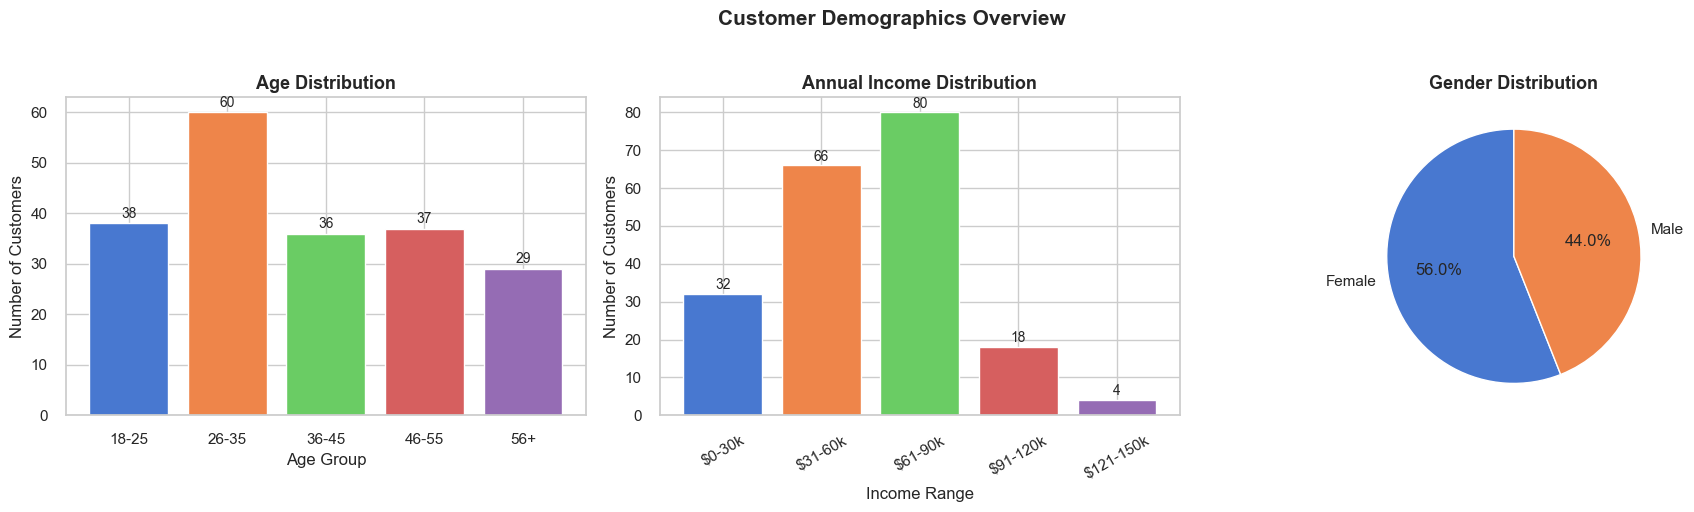

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Age Distribution ---
age_bins   = ['18-25', '26-35', '36-45', '46-55', '56+']
age_counts = [
    df['Age'][(df['Age'] >= 18) & (df['Age'] <= 25)].count(),
    df['Age'][(df['Age'] >= 26) & (df['Age'] <= 35)].count(),
    df['Age'][(df['Age'] >= 36) & (df['Age'] <= 45)].count(),
    df['Age'][(df['Age'] >= 46) & (df['Age'] <= 55)].count(),
    df['Age'][df['Age'] >= 56].count(),
]
bars = axes[0].bar(age_bins, age_counts, color=sns.color_palette('muted', 5))
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, age_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.5, str(val),
                 ha='center', va='bottom', fontsize=10)

# --- Annual Income Distribution ---
income_bins   = ['$0-30k', '$31-60k', '$61-90k', '$91-120k', '$121-150k']
income_counts = [
    df['Annual_Income'][(df['Annual_Income'] >= 0)   & (df['Annual_Income'] <= 30)].count(),
    df['Annual_Income'][(df['Annual_Income'] >= 31)  & (df['Annual_Income'] <= 60)].count(),
    df['Annual_Income'][(df['Annual_Income'] >= 61)  & (df['Annual_Income'] <= 90)].count(),
    df['Annual_Income'][(df['Annual_Income'] >= 91)  & (df['Annual_Income'] <= 120)].count(),
    df['Annual_Income'][(df['Annual_Income'] >= 121) & (df['Annual_Income'] <= 150)].count(),
]
bars = axes[1].bar(income_bins, income_counts, color=sns.color_palette('muted', 5))
axes[1].set_title('Annual Income Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Income Range')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, income_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5, str(val),
                 ha='center', va='bottom', fontsize=10)

# --- Gender Distribution ---
gender_counts = df['Gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('muted', 2))
axes[2].set_title('Gender Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Customer Demographics Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

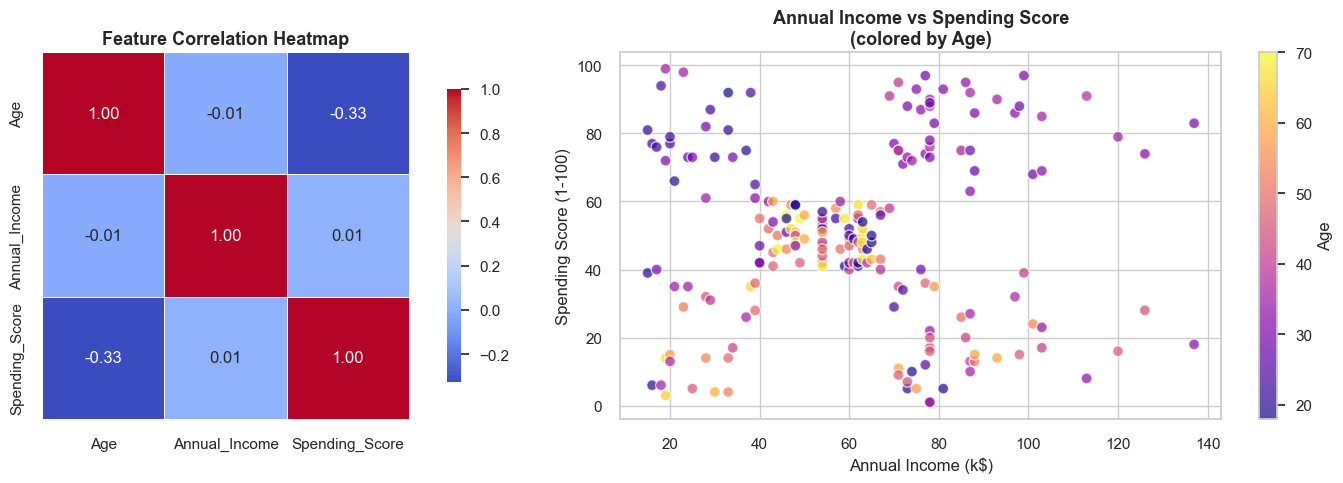

In [11]:
# Correlation heatmap + scatter untuk melihat hubungan antar fitur
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
numeric_cols = ['Age', 'Annual_Income', 'Spending_Score']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Scatter: Income vs Spending (unlabeled baseline)
scatter = axes[1].scatter(df['Annual_Income'], df['Spending_Score'],
                          c=df['Age'], cmap='plasma', s=60, alpha=0.7, edgecolors='w')
plt.colorbar(scatter, ax=axes[1], label='Age')
axes[1].set_title('Annual Income vs Spending Score\n(colored by Age)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Scaling

K-Means menggunakan jarak Euclidean — fitur dengan skala besar akan mendominasi. Oleh karena itu kita perlu **StandardScaler** sebelum clustering.

- **2D**: `Annual_Income` + `Spending_Score` (primary clustering)
- **3D**: `Age` + `Annual_Income` + `Spending_Score` (multivariate clustering)

In [12]:
scaler = StandardScaler()

# 2D features (raw + scaled)
X2_raw    = df[['Annual_Income', 'Spending_Score']].values
X2_scaled = scaler.fit_transform(X2_raw)

# 3D features (scaled)
X3_raw    = df[['Age', 'Annual_Income', 'Spending_Score']].values
X3_scaled = scaler.fit_transform(X3_raw)

print("2D feature matrix (scaled) — first 5 rows:")
print(pd.DataFrame(X2_scaled, columns=['Annual_Income_scaled', 'Spending_Score_scaled']).head())
print(f"\nShape X2: {X2_scaled.shape} | Shape X3: {X3_scaled.shape}")

2D feature matrix (scaled) — first 5 rows:
   Annual_Income_scaled  Spending_Score_scaled
0             -1.738999              -0.434801
1             -1.738999               1.195704
2             -1.700830              -1.715913
3             -1.700830               1.040418
4             -1.662660              -0.395980

Shape X2: (200, 2) | Shape X3: (200, 3)


## 5. Optimal Cluster Selection

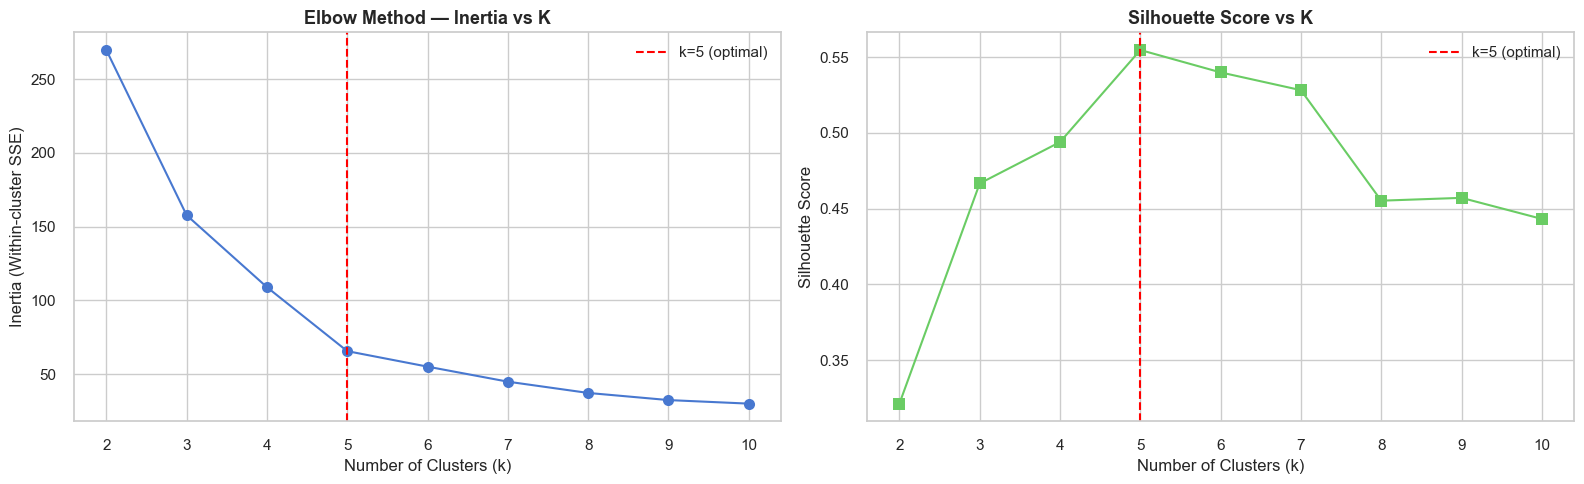

=== Cluster Evaluation Summary ===
 k  Inertia  Silhouette Score
 2   269.69            0.3213
 3   157.70            0.4666
 4   108.92            0.4939
 5    65.57            0.5547
 6    55.06            0.5399
 7    44.86            0.5281
 8    37.23            0.4552
 9    32.39            0.4571
10    29.98            0.4432

Best k by Silhouette: k=5


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

K_range = range(2, 11)
inertias          = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X2_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X2_scaled, km.labels_))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].axvline(x=5, color='red', linestyle='--', label='k=5 (optimal)')
axes[0].legend()

# Silhouette score curve
axes[1].plot(list(K_range), silhouette_scores, 'gs-', markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=5, color='red', linestyle='--', label='k=5 (optimal)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary table
print("=== Cluster Evaluation Summary ===")
summary = pd.DataFrame({
    'k': list(K_range),
    'Inertia': [round(i, 2) for i in inertias],
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
print(summary.to_string(index=False))
print(f"\nBest k by Silhouette: k={list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")

## 6. K-Means Clustering — 2D (Income vs Spending)

In [14]:
OPTIMAL_K = 5

kmeans_2d = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_2d.fit(X2_scaled)

df['Cluster_2D'] = kmeans_2d.labels_

score_2d = silhouette_score(X2_scaled, kmeans_2d.labels_)
print(f"K-Means (k={OPTIMAL_K}) Silhouette Score: {score_2d:.4f}")

# Cluster profile summary
profile = df.groupby('Cluster_2D')[['Annual_Income', 'Spending_Score', 'Age']].mean().round(2)
profile['Size']     = df['Cluster_2D'].value_counts().sort_index()
profile['% Female'] = df.groupby('Cluster_2D')['Gender'].apply(
    lambda x: round((x == 'Female').sum() / len(x) * 100, 1))
print("\n=== Cluster Profile (2D) ===")
print(profile)

K-Means (k=5) Silhouette Score: 0.5547

=== Cluster Profile (2D) ===
            Annual_Income  Spending_Score    Age  Size  % Female
Cluster_2D                                                      
0                   55.30           49.52  42.72    81      59.3
1                   86.54           82.13  32.69    39      53.8
2                   25.73           79.36  25.27    22      59.1
3                   88.20           17.11  41.11    35      45.7
4                   26.30           20.91  45.22    23      60.9


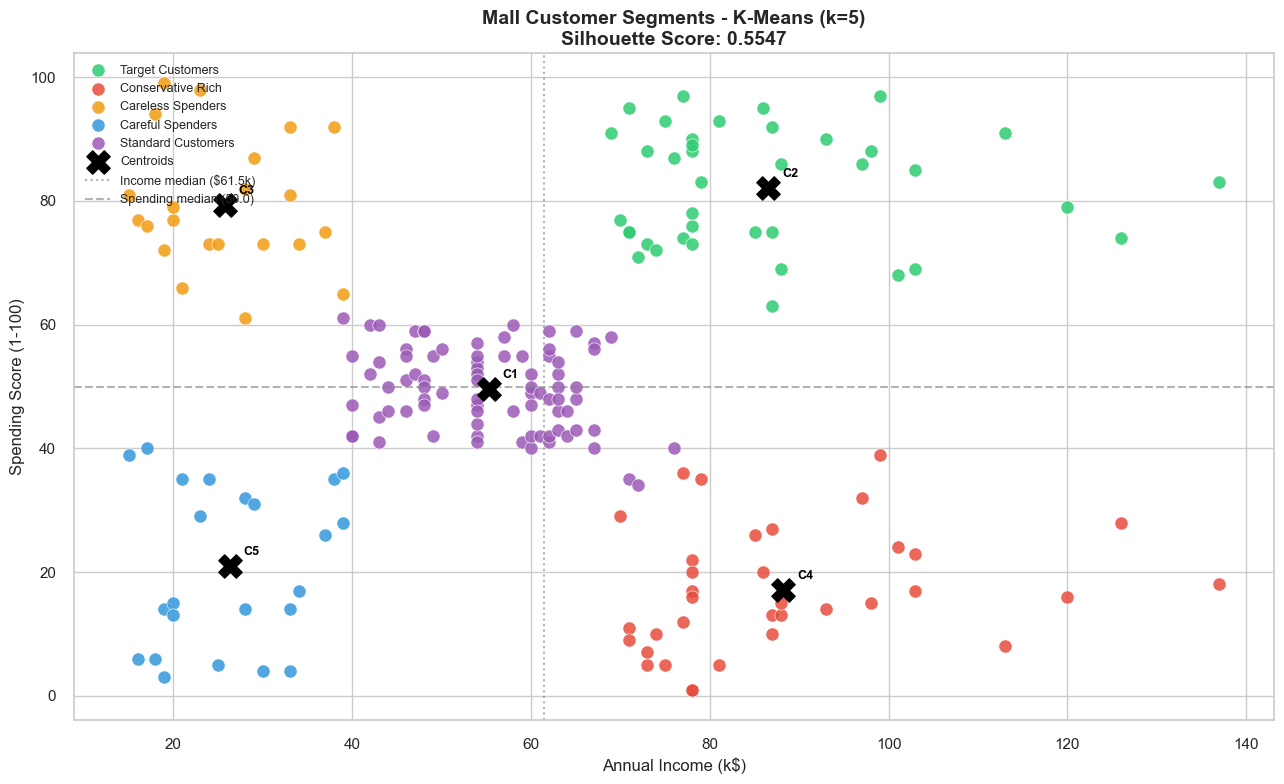


=== Segment Distribution ===
Segment
Standard Customers    81
Target Customers      39
Conservative Rich     35
Careful Spenders      23
Careless Spenders     22


In [15]:
# Auto-assign segment names berdasarkan Income & Spending centroid
centroids_raw = df.groupby('Cluster_2D')[['Annual_Income', 'Spending_Score']].mean()
inc_med = df['Annual_Income'].median()
spd_med = df['Spending_Score'].median()

def auto_label(row):
    hi_inc = row['Annual_Income'] >= inc_med
    hi_spd = row['Spending_Score'] >= spd_med
    if hi_inc and hi_spd:
        return 'Target Customers'      # High Income, High Spend
    elif hi_inc and not hi_spd:
        return 'Conservative Rich'     # High Income, Low Spend
    elif not hi_inc and hi_spd:
        return 'Careless Spenders'     # Low Income, High Spend
    else:
        return 'Careful Spenders'      # Low Income, Low Spend

label_map = centroids_raw.apply(auto_label, axis=1).to_dict()

# Cluster terdekat ke median -> Standard Customers
dist_to_center = ((centroids_raw - centroids_raw.mean()) ** 2).sum(axis=1)
mid_cluster = dist_to_center.idxmin()
label_map[mid_cluster] = 'Standard Customers'

df['Segment'] = df['Cluster_2D'].map(label_map)

# --- Visualization ---
PALETTE = {
    'Target Customers'   : '#2ecc71',
    'Conservative Rich'  : '#e74c3c',
    'Careless Spenders'  : '#f39c12',
    'Careful Spenders'   : '#3498db',
    'Standard Customers' : '#9b59b6',
}

fig, ax = plt.subplots(figsize=(13, 8))

for segment, color in PALETTE.items():
    mask = df['Segment'] == segment
    if mask.any():
        ax.scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                   s=90, alpha=0.85, edgecolors='white', linewidths=0.5,
                   color=color, label=segment)

# Centroids
cx = centroids_raw['Annual_Income'].values
cy = centroids_raw['Spending_Score'].values
ax.scatter(cx, cy, c='black', s=280, marker='X', zorder=5, label='Centroids')
for idx in range(len(cx)):
    ax.annotate(f'C{idx+1}', (cx[idx], cy[idx]),
                textcoords='offset points', xytext=(10, 8),
                fontsize=9, fontweight='bold', color='black')

# Median lines
ax.axvline(inc_med, color='gray', linestyle=':', alpha=0.6, label=f'Income median (${inc_med}k)')
ax.axhline(spd_med, color='gray', linestyle='--', alpha=0.6, label=f'Spending median ({spd_med})')

ax.set_title(f'Mall Customer Segments - K-Means (k={OPTIMAL_K})\nSilhouette Score: {score_2d:.4f}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# Segment distribution
print("\n=== Segment Distribution ===")
print(df['Segment'].value_counts().to_string())

## 7. Multivariate Clustering — 3D (Age + Income + Spending)

Menambahkan fitur `Age` untuk mendapatkan segmentasi yang lebih kaya secara demografis.

Best k for 3D clustering: 6 (Silhouette: 0.4284)


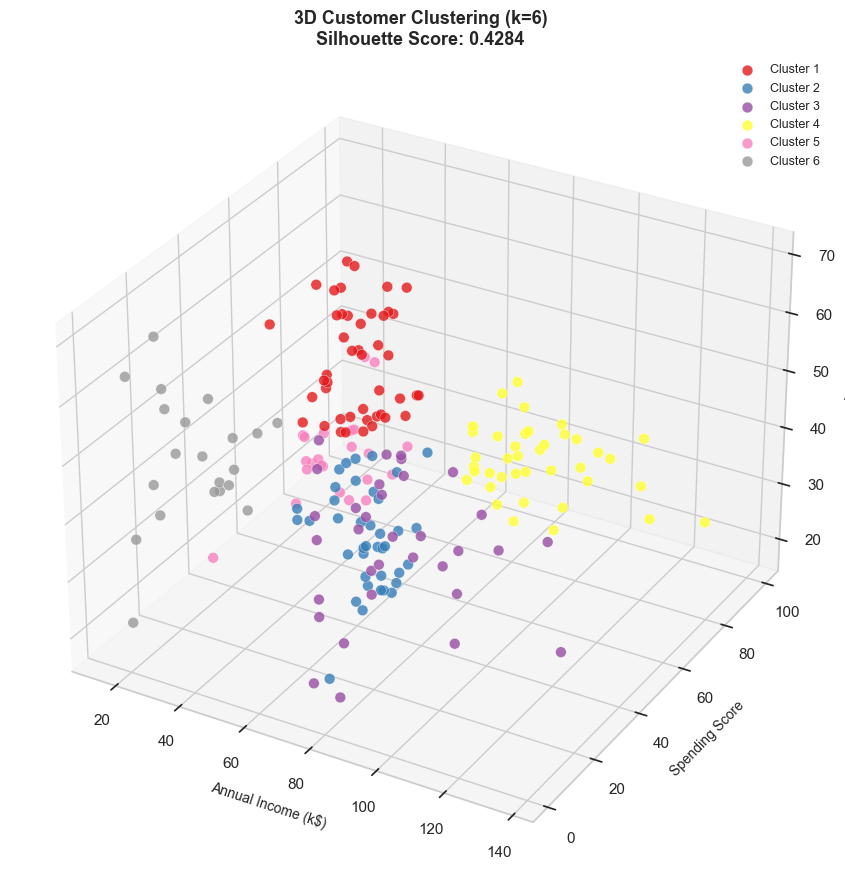


=== 3D Cluster Profile ===
              Age  Annual_Income  Spending_Score  Size
Cluster_3D                                            
0           56.33          54.27           49.07    45
1           26.79          57.10           48.13    39
2           41.94          88.94           16.97    33
3           32.69          86.54           82.13    39
4           25.00          25.26           77.61    23
5           45.52          26.29           19.38    21


In [16]:
# Cari optimal k untuk 3D features
sil_3d = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X3_scaled)
    sil_3d.append(silhouette_score(X3_scaled, km.labels_))

best_k_3d = list(range(2, 11))[sil_3d.index(max(sil_3d))]
print(f"Best k for 3D clustering: {best_k_3d} (Silhouette: {max(sil_3d):.4f})")

kmeans_3d = KMeans(n_clusters=best_k_3d, random_state=42, n_init=10)
kmeans_3d.fit(X3_scaled)
df['Cluster_3D'] = kmeans_3d.labels_

score_3d = silhouette_score(X3_scaled, kmeans_3d.labels_)

# 3D scatter plot
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

colors_3d = plt.cm.Set1(np.linspace(0, 1, best_k_3d))
for cid, color in enumerate(colors_3d):
    mask = df['Cluster_3D'] == cid
    ax.scatter(df.loc[mask, 'Annual_Income'],
               df.loc[mask, 'Spending_Score'],
               df.loc[mask, 'Age'],
               color=color, s=60, alpha=0.8, edgecolors='white',
               linewidths=0.3, label=f'Cluster {cid+1}')

ax.set_xlabel('Annual Income (k$)', fontsize=10, labelpad=10)
ax.set_ylabel('Spending Score', fontsize=10, labelpad=10)
ax.set_zlabel('Age', fontsize=10, labelpad=10)
ax.set_title(f'3D Customer Clustering (k={best_k_3d})\nSilhouette Score: {score_3d:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Profile
profile_3d = df.groupby('Cluster_3D')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(2)
profile_3d['Size'] = df['Cluster_3D'].value_counts().sort_index()
print("\n=== 3D Cluster Profile ===")
print(profile_3d)

## 8. Cluster Interpretation & Business Insights

In [17]:
# Segment profile detail + business recommendations
segment_summary = df.groupby('Segment').agg(
    Count        = ('CustomerID', 'count'),
    Avg_Age      = ('Age', 'mean'),
    Avg_Income   = ('Annual_Income', 'mean'),
    Avg_Spending = ('Spending_Score', 'mean'),
    Female_Pct   = ('Gender', lambda x: round((x == 'Female').mean() * 100, 1))
).round(2).sort_values('Avg_Income', ascending=False)

print("=" * 65)
print("CUSTOMER SEGMENT PROFILE SUMMARY")
print("=" * 65)
print(segment_summary.to_string())
print()

insights = {
    'Target Customers': {
        'desc'  : 'High income, high spending — most valuable segment.',
        'action': 'Prioritize with loyalty rewards, exclusive memberships, premium products.',
    },
    'Conservative Rich': {
        'desc'  : 'High income but low spending — untapped potential.',
        'action': 'Target with personalized offers, quality messaging, trust-building campaigns.',
    },
    'Careless Spenders': {
        'desc'  : 'Low income but high spending — impulse buyers.',
        'action': 'Drive engagement with flash sales, buy-now-pay-later, affordable bundles.',
    },
    'Careful Spenders': {
        'desc'  : 'Low income, low spending — price-sensitive segment.',
        'action': 'Attract with discount programs, value deals, budget-friendly promotions.',
    },
    'Standard Customers': {
        'desc'  : 'Mid-range income and spending — the average customer.',
        'action': 'Nurture with general campaigns, cross-sell, seasonal promotions.',
    },
}

print("=" * 65)
print("BUSINESS RECOMMENDATIONS PER SEGMENT")
print("=" * 65)
for seg, info in insights.items():
    count = segment_summary.loc[seg, 'Count'] if seg in segment_summary.index else 'N/A'
    print(f"\n[{seg}] (n={count})")
    print(f"  Profile : {info['desc']}")
    print(f"  Strategy: {info['action']}")

CUSTOMER SEGMENT PROFILE SUMMARY
                    Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Segment                                                                 
Conservative Rich      35    41.11       88.20         17.11        45.7
Target Customers       39    32.69       86.54         82.13        53.8
Standard Customers     81    42.72       55.30         49.52        59.3
Careful Spenders       23    45.22       26.30         20.91        60.9
Careless Spenders      22    25.27       25.73         79.36        59.1

BUSINESS RECOMMENDATIONS PER SEGMENT

[Target Customers] (n=39)
  Profile : High income, high spending — most valuable segment.
  Strategy: Prioritize with loyalty rewards, exclusive memberships, premium products.

[Conservative Rich] (n=35)
  Profile : High income but low spending — untapped potential.
  Strategy: Target with personalized offers, quality messaging, trust-building campaigns.

[Careless Spenders] (n=22)
  Profile : Low income but high 

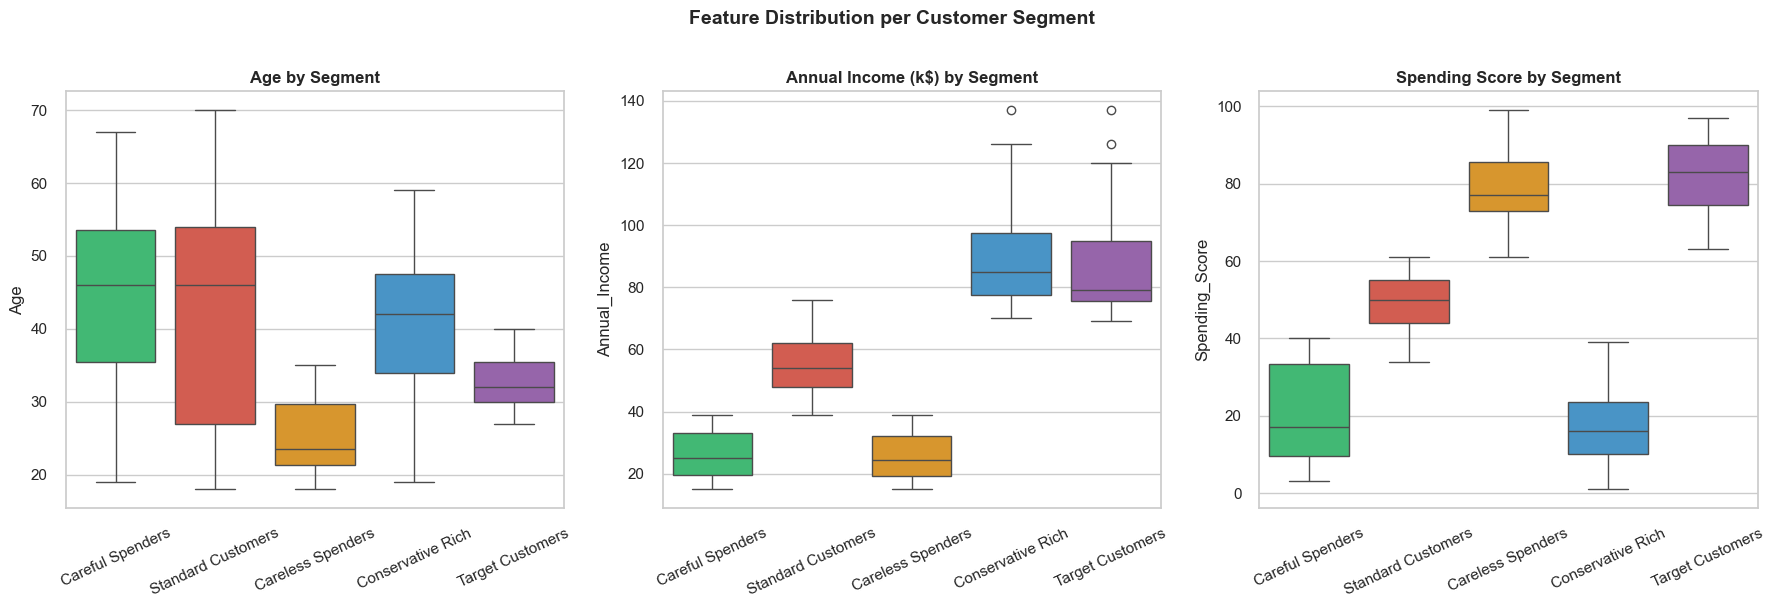


Final Silhouette Scores:
  2D Clustering (k=5)  : 0.5547
  3D Clustering (k=6) : 0.4284


In [18]:
# Boxplot distribusi per segment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seg_order = ['Careful Spenders', 'Standard Customers', 'Careless Spenders',
             'Conservative Rich', 'Target Customers']
seg_order = [s for s in seg_order if s in df['Segment'].unique()]

for ax, col, title in zip(axes,
                           ['Age', 'Annual_Income', 'Spending_Score'],
                           ['Age by Segment', 'Annual Income (k$) by Segment', 'Spending Score by Segment']):
    sns.boxplot(data=df, x='Segment', y=col, order=seg_order,
                palette=list(PALETTE.values()), ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Feature Distribution per Customer Segment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nFinal Silhouette Scores:")
print(f"  2D Clustering (k={OPTIMAL_K})  : {score_2d:.4f}")
print(f"  3D Clustering (k={best_k_3d}) : {score_3d:.4f}")